# 05 — Random Forest modeling

Doel: voor elk van de 4 (asset × window) combinaties een Random Forest **classifier**
(direction) en **regressor** (magnitude) trainen, vergelijken met baselines, en
evalueren met de evaluatiemetrieken die we in de scriptie willen rapporteren.

**Plan:**
1. Load feature artifacts uit notebook 04.
2. Baselines: Dummy, L1-Logistic (cls), Ridge (reg).
3. Random Forest classifier en regressor per target.
4. **Classificatie evaluatie**: accuracy, macro-F1, confusion matrix, ROC AUC.
5. **Regressie evaluatie**: RMSE, MAE, R², directional accuracy, pred-vs-actual scatter, residuals.
6. **Vergelijking** RF ↔ baselines via bar charts.
7. Save alle modellen voor notebook 06 (interpretability).

**Verwachting voor synthetic data**: RF gaat amper baselines kloppen omdat de
synthetic posts geen causaal signal hebben. Dat is geen bug — het toont dat
onze pipeline correct flagt wanneer er geen signal is. Zodra je echte data
gebruikt, zou je een meetbare improvement moeten zien.


In [1]:
%load_ext autoreload
%autoreload 2

import sys
import warnings
from pathlib import Path

sys.path.insert(0, str(Path.cwd().parent))

import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.dummy import DummyClassifier, DummyRegressor
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.linear_model import LogisticRegression, Ridge
from sklearn.metrics import (accuracy_score, classification_report,
                             confusion_matrix, f1_score, mean_absolute_error,
                             mean_squared_error, r2_score, roc_auc_score)

sns.set_theme(style="whitegrid", context="notebook")
warnings.filterwarnings("ignore")

print(f"pandas={pd.__version__}, numpy={np.__version__}")

pandas=3.0.2, numpy=2.4.4


## 1. Load artifacts uit notebook 04


In [2]:
art_dir = Path("../data/processed/features")
features = joblib.load(art_dir / "features.joblib")
targets = joblib.load(art_dir / "targets.joblib")
metadata = joblib.load(art_dir / "metadata.joblib")

X_train = features["X_train"]
X_test = features["X_test"]
feature_names = features["feature_names"]
TARGET_COLS = metadata["target_cols"]

print(f"X_train: {X_train.shape}, X_test: {X_test.shape}")
print(f"Features: {len(feature_names)} (last 3 = engagement)")
print(f"Targets: {TARGET_COLS}")
print(f"Cutoff date: {metadata['split_date']}")
print(f"Dead zone: {metadata['dead_zone']}")

X_train: (14099, 5003), X_test: (3525, 5003)
Features: 5003 (last 3 = engagement)
Targets: ['ar_1d_spx', 'car_3d_spx', 'ar_1d_wti', 'car_3d_wti']
Cutoff date: 2025-04-29T15:38:02.670000+00:00
Dead zone: 0.001


## 2. Helper functies

Eén plek voor alle evaluatiemetrieken zodat de tabellen consistent zijn.


In [3]:
def eval_classifier(model, X_te, y_te) -> dict:
    pred = model.predict(X_te)
    metrics = {
        "accuracy": accuracy_score(y_te, pred),
        "f1_macro": f1_score(y_te, pred, average="macro"),
        "f1_weighted": f1_score(y_te, pred, average="weighted"),
    }
    if hasattr(model, "predict_proba"):
        try:
            proba = model.predict_proba(X_te)
            classes = model.classes_
            # one-vs-rest macro AUC
            metrics["roc_auc_ovr"] = roc_auc_score(y_te, proba, multi_class="ovr", labels=classes)
        except Exception:
            metrics["roc_auc_ovr"] = np.nan
    return metrics


def eval_regressor(model, X_te, y_te) -> dict:
    pred = model.predict(X_te)
    return {
        "rmse": float(np.sqrt(mean_squared_error(y_te, pred))),
        "mae": float(mean_absolute_error(y_te, pred)),
        "r2": float(r2_score(y_te, pred)),
        "directional_accuracy": float(((pred > 0) == (y_te > 0)).mean()),
    }


def drop_nans(X, y):
    """Sync drop NaNs voor regressie-targets met scope op laatste rijen."""
    mask = ~pd.isna(y)
    return X[mask.values], np.asarray(y[mask])

## 3. Train alle modellen

Voor elke target trainen we 4 modellen voor classificatie (Dummy, Logistic-L1, RF)
en 3 voor regressie (Dummy, Ridge, RF). Resultaten in twee dicts.


In [5]:
# Conservatief RF voor snelle iteratie. Voor je productie run: n_estimators=300-500
# en max_depth=None (laat trees volgroeien). Notebook 05 in repo skeleton config.yaml
# heeft de productie-defaults (n_estimators=500).
RF_PARAMS = dict(
    n_estimators=100,
    max_depth=12,
    min_samples_split=10,
    min_samples_leaf=5,
    n_jobs=-1,
    random_state=42,
    class_weight="balanced",
)

cls_results = {}   # {target: {model_name: {model, metrics}}}
reg_results = {}

for col in TARGET_COLS:
    print(f"\n=== {col} ===")
    cls_results[col] = {}
    reg_results[col] = {}

    # ---- Classification ----
    y_tr = targets["classification"]["train"][col]
    y_te = targets["classification"]["test"][col]

    Xtr_cls, ytr_cls = drop_nans(X_train, y_tr)
    Xte_cls, yte_cls = drop_nans(X_test, y_te)

    for name, model in [
        ("dummy", DummyClassifier(strategy="stratified", random_state=42)),
        ("logistic_l1", LogisticRegression(penalty="l1", C=1.0, solver="saga",
                                            max_iter=2000, random_state=42)),
        ("rf", RandomForestClassifier(**{**RF_PARAMS})),
    ]:
        model.fit(Xtr_cls, ytr_cls)
        m = eval_classifier(model, Xte_cls, yte_cls)
        cls_results[col][name] = {"model": model, "metrics": m,
                                    "y_test": yte_cls, "X_test": Xte_cls}
        print(f"  cls {name:12s} acc={m['accuracy']:.3f} f1={m['f1_macro']:.3f} auc={m.get('roc_auc_ovr', float('nan')):.3f}")

    # ---- Regression ----
    y_tr_r = targets["regression"]["train"][col]
    y_te_r = targets["regression"]["test"][col]

    Xtr_reg, ytr_reg = drop_nans(X_train, y_tr_r)
    Xte_reg, yte_reg = drop_nans(X_test, y_te_r)

    rf_reg_params = {k: v for k, v in RF_PARAMS.items() if k != "class_weight"}
    for name, model in [
        ("dummy", DummyRegressor(strategy="mean")),
        ("ridge", Ridge(alpha=1.0, random_state=42)),
        ("rf", RandomForestRegressor(**rf_reg_params)),
    ]:
        model.fit(Xtr_reg, ytr_reg)
        m = eval_regressor(model, Xte_reg, yte_reg)
        reg_results[col][name] = {"model": model, "metrics": m,
                                    "y_test": yte_reg, "X_test": Xte_reg}
        print(f"  reg {name:12s} rmse={m['rmse']:.5f} mae={m['mae']:.5f} r2={m['r2']:+.4f} dir_acc={m['directional_accuracy']:.3f}")


=== ar_1d_spx ===
  cls dummy        acc=0.348 f1=0.344 auc=0.508
  cls logistic_l1  acc=0.365 f1=0.330 auc=0.529
  cls rf           acc=0.379 f1=0.368 auc=0.550
  reg dummy        rmse=0.00833 mae=0.00610 r2=-0.0142 dir_acc=0.456
  reg ridge        rmse=0.00953 mae=0.00724 r2=-0.3279 dir_acc=0.496
  reg rf           rmse=0.00849 mae=0.00625 r2=-0.0547 dir_acc=0.463

=== car_3d_spx ===
  cls dummy        acc=0.369 f1=0.337 auc=0.503
  cls logistic_l1  acc=0.390 f1=0.300 auc=0.494
  cls rf           acc=0.322 f1=0.307 auc=0.484
  reg dummy        rmse=0.01376 mae=0.01051 r2=-0.0105 dir_acc=0.500
  reg ridge        rmse=0.01568 mae=0.01221 r2=-0.3116 dir_acc=0.513
  reg rf           rmse=0.01409 mae=0.01077 r2=-0.0594 dir_acc=0.502

=== ar_1d_wti ===
  cls dummy        acc=0.388 f1=0.336 auc=0.502
  cls logistic_l1  acc=0.432 f1=0.307 auc=0.515
  cls rf           acc=0.377 f1=0.327 auc=0.499
  reg dummy        rmse=0.03290 mae=0.02137 r2=-0.0002 dir_acc=0.464
  reg ridge        rmse=0.0

## 4. Classificatie evaluatie

### 4.1 Confusion matrices


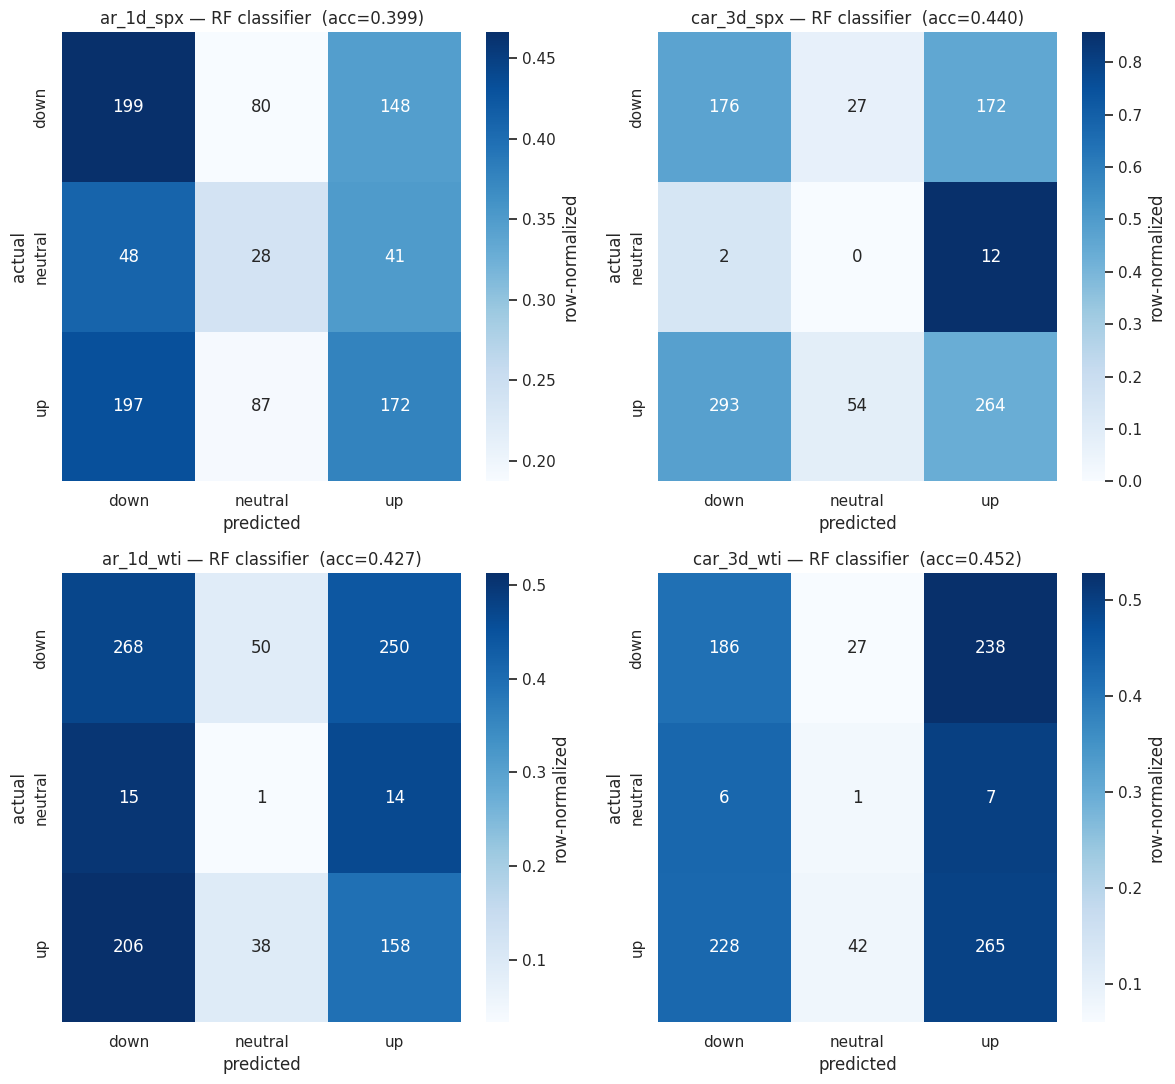

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(12, 11))
for ax, col in zip(axes.flat, TARGET_COLS):
    rf = cls_results[col]["rf"]["model"]
    y_te = cls_results[col]["rf"]["y_test"]
    X_te = cls_results[col]["rf"]["X_test"]
    pred = rf.predict(X_te)
    labels = ["down", "neutral", "up"]
    cm = confusion_matrix(y_te, pred, labels=labels)
    cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True).clip(min=1)
    sns.heatmap(cm_norm, annot=cm, fmt="d", cmap="Blues",
                xticklabels=labels, yticklabels=labels,
                cbar_kws={"label": "row-normalized"}, ax=ax)
    ax.set_title(f"{col} — RF classifier  (acc={cls_results[col]['rf']['metrics']['accuracy']:.3f})")
    ax.set_xlabel("predicted")
    ax.set_ylabel("actual")
fig.tight_layout()
plt.show()

### 4.2 Classificatie-metrics tabel (RF vs baselines)


In [ ]:
rows = []
for col in TARGET_COLS:
    for name in ["dummy", "logistic_l1", "rf"]:
        m = cls_results[col][name]["metrics"]
        rows.append({"target": col, "model": name, **m})
cls_table = pd.DataFrame(rows).pivot(index="target", columns="model", values=["accuracy", "f1_macro", "roc_auc_ovr"]).round(3)
cls_table

accuracy                    f1_macro                     \
model         dummy logistic_l1     rf    dummy logistic_l1     rf   
target                                                               
ar_1d_spx     0.401       0.441  0.399    0.328       0.279  0.352   
ar_1d_wti     0.455       0.500  0.427    0.327       0.309  0.302   
car_3d_spx    0.484       0.472  0.440    0.340       0.310  0.305   
car_3d_wti    0.466       0.491  0.452    0.316       0.279  0.319   

           roc_auc_ovr                     
model            dummy logistic_l1     rf  
target                                     
ar_1d_spx        0.494       0.523  0.512  
ar_1d_wti        0.495       0.478  0.475  
car_3d_spx       0.515       0.512  0.510  
car_3d_wti       0.485       0.450  0.476

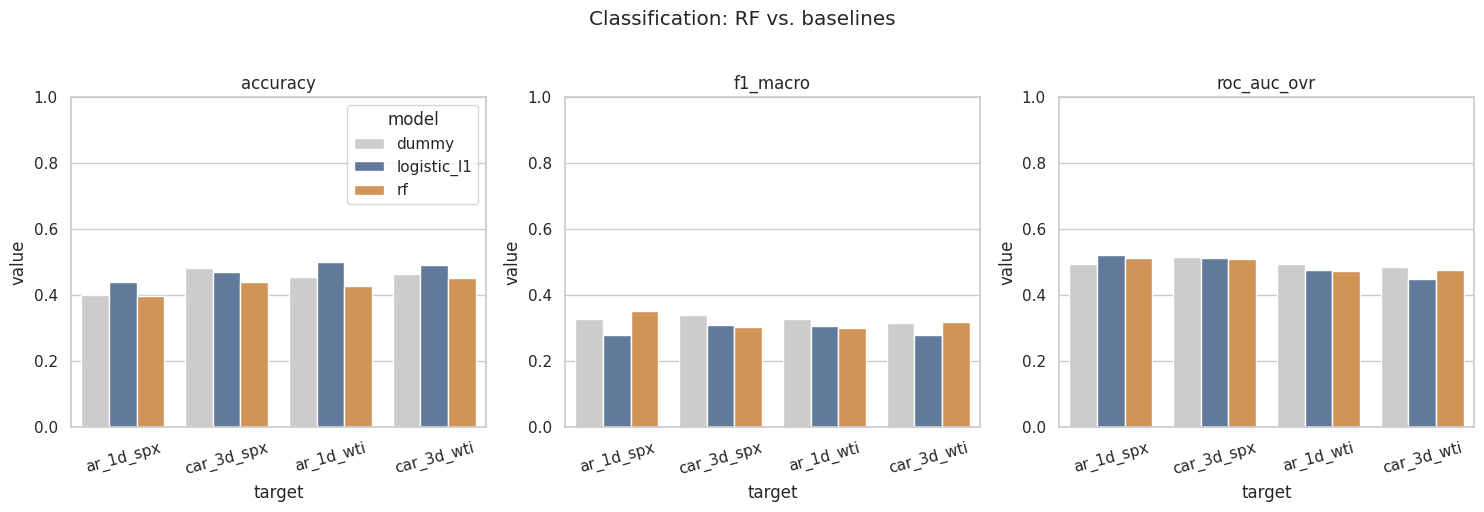

In [ ]:
# Visualize RF lift over baselines
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
metric_names = ["accuracy", "f1_macro", "roc_auc_ovr"]
for ax, metric in zip(axes, metric_names):
    df_long = pd.DataFrame([
        {"target": c, "model": m, "value": cls_results[c][m]["metrics"].get(metric, np.nan)}
        for c in TARGET_COLS for m in ["dummy", "logistic_l1", "rf"]
    ])
    sns.barplot(data=df_long, x="target", y="value", hue="model", ax=ax,
                palette=["#cccccc", "#5778a4", "#e49444"])
    ax.set_title(metric)
    ax.set_ylim(0, 1)
    ax.tick_params(axis="x", rotation=15)
    if metric != "accuracy":
        ax.legend_.remove()
fig.suptitle("Classification: RF vs. baselines", y=1.02)
fig.tight_layout()
plt.show()

## 5. Regressie evaluatie

### 5.1 Predicted vs. actual scatter


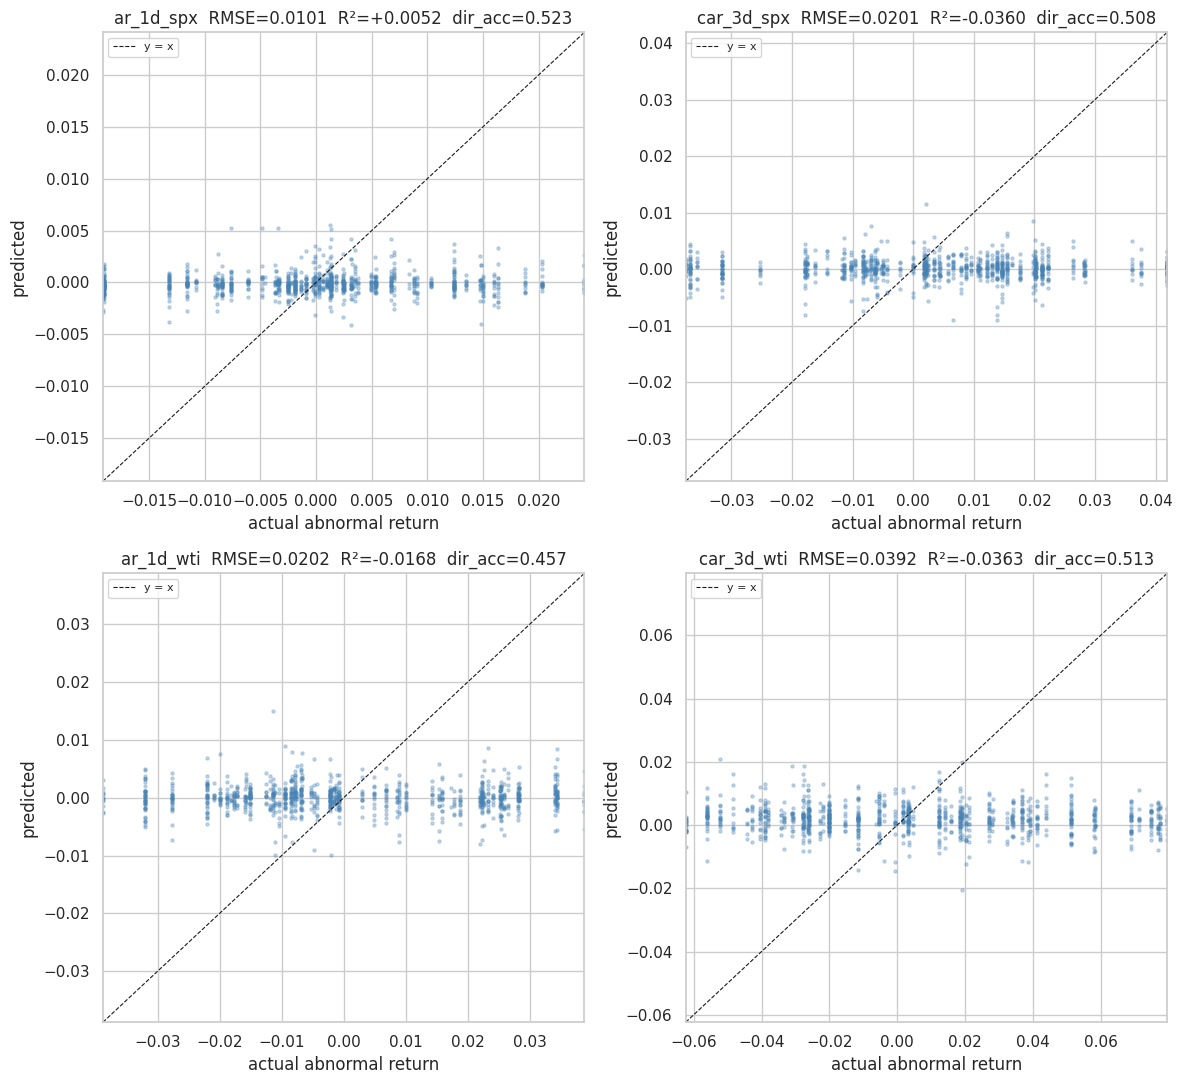

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(12, 11))
for ax, col in zip(axes.flat, TARGET_COLS):
    rf = reg_results[col]["rf"]["model"]
    y_te = reg_results[col]["rf"]["y_test"]
    X_te = reg_results[col]["rf"]["X_test"]
    pred = rf.predict(X_te)
    m = reg_results[col]["rf"]["metrics"]

    # Limit to inner 99% to avoid extreme outliers compressing axes
    lo, hi = np.percentile(np.concatenate([y_te, pred]), [0.5, 99.5])
    ax.scatter(y_te, pred, s=5, alpha=0.3, color="steelblue")
    ax.plot([lo, hi], [lo, hi], "k--", linewidth=0.8, label="y = x")
    ax.set_xlim(lo, hi); ax.set_ylim(lo, hi)
    ax.set_title(f"{col}  RMSE={m['rmse']:.4f}  R²={m['r2']:+.4f}  dir_acc={m['directional_accuracy']:.3f}")
    ax.set_xlabel("actual abnormal return")
    ax.set_ylabel("predicted")
    ax.legend(loc="upper left", fontsize=8)
fig.tight_layout()
plt.show()

### 5.2 Residuals distributie

Residuals = actual − predicted. Zou ongeveer normaal verdeeld moeten zijn rond 0.
Skewness of fat tails wijzen op systematische bias.


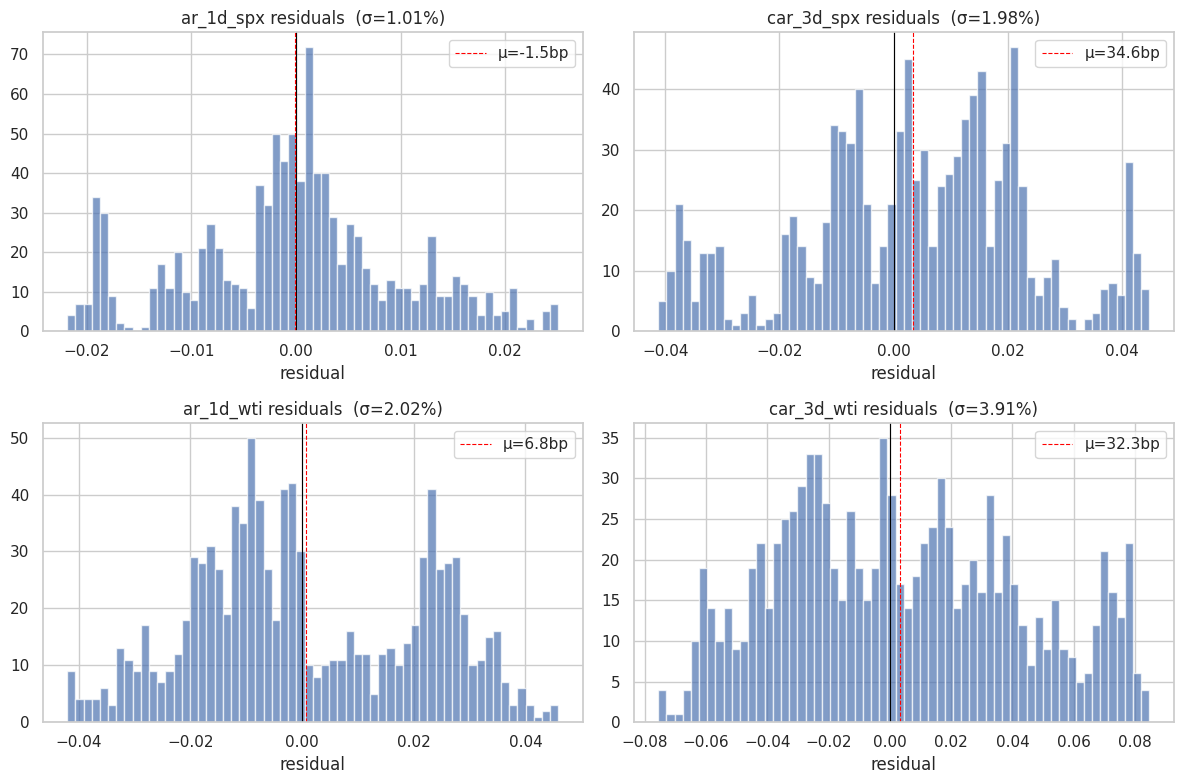

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
for ax, col in zip(axes.flat, TARGET_COLS):
    rf = reg_results[col]["rf"]["model"]
    y_te = reg_results[col]["rf"]["y_test"]
    X_te = reg_results[col]["rf"]["X_test"]
    residuals = y_te - rf.predict(X_te)
    ax.hist(residuals, bins=60, alpha=0.7, edgecolor="white")
    ax.axvline(0, color="black", linewidth=0.8)
    ax.axvline(residuals.mean(), color="red", linestyle="--", linewidth=0.8,
               label=f"μ={residuals.mean()*1e4:.1f}bp")
    ax.set_title(f"{col} residuals  (σ={residuals.std()*100:.2f}%)")
    ax.set_xlabel("residual")
    ax.legend()
fig.tight_layout()
plt.show()

### 5.3 Regressie-metrics tabel (RF vs baselines)


In [ ]:
rows = []
for col in TARGET_COLS:
    for name in ["dummy", "ridge", "rf"]:
        m = reg_results[col][name]["metrics"]
        rows.append({"target": col, "model": name, **m})
reg_table = pd.DataFrame(rows).pivot(
    index="target", columns="model",
    values=["rmse", "mae", "r2", "directional_accuracy"]
).round(5)
reg_table

rmse                        mae                         r2  \
model         dummy       rf    ridge    dummy       rf    ridge    dummy   
target                                                                      
ar_1d_spx   0.01009  0.01006  0.01011  0.00765  0.00764  0.00769 -0.00022   
ar_1d_wti   0.02003  0.02018  0.02039  0.01691  0.01706  0.01723 -0.00083   
car_3d_spx  0.02009  0.02013  0.02037  0.01628  0.01630  0.01650 -0.03184   
car_3d_wti  0.03862  0.03920  0.03946  0.03227  0.03277  0.03313 -0.00620   

                             directional_accuracy                
model            rf    ridge                dummy     rf  ridge  
target                                                           
ar_1d_spx   0.00521 -0.00449                0.490  0.523  0.514  
ar_1d_wti  -0.01678 -0.03800                0.402  0.457  0.458  
car_3d_spx -0.03601 -0.06082                0.611  0.508  0.477  
car_3d_wti -0.03628 -0.05029                0.535  0.513  0.471

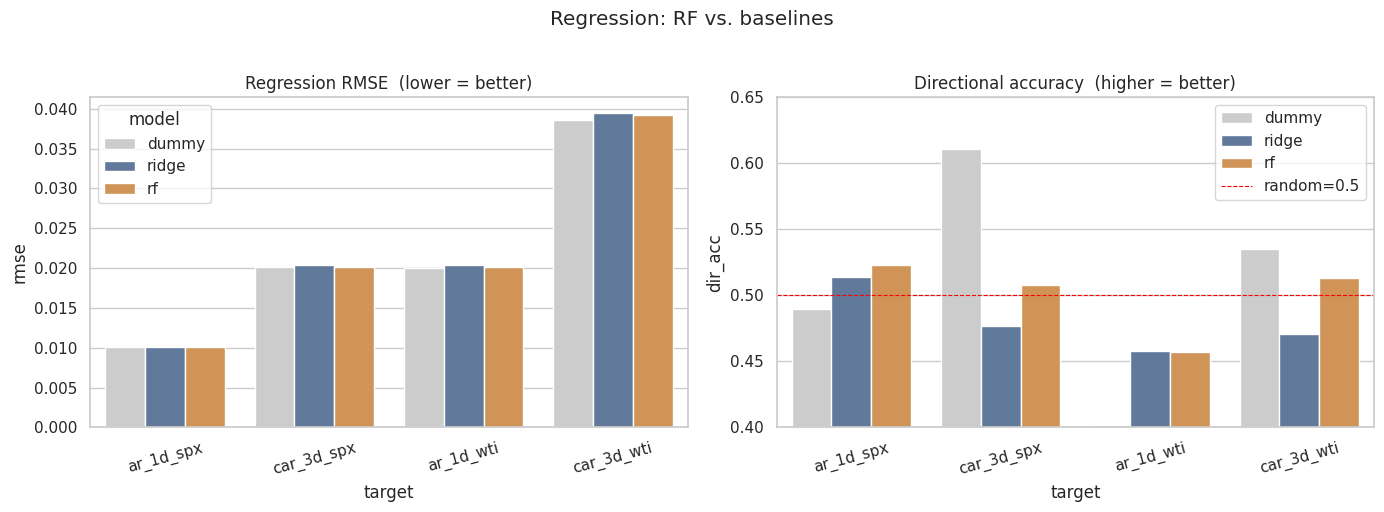

In [ ]:
# Visualize: bar chart RMSE en R² per target/model
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# RMSE — lower is better
df_rmse = pd.DataFrame([
    {"target": c, "model": m, "rmse": reg_results[c][m]["metrics"]["rmse"]}
    for c in TARGET_COLS for m in ["dummy", "ridge", "rf"]
])
sns.barplot(data=df_rmse, x="target", y="rmse", hue="model", ax=axes[0],
            palette=["#cccccc", "#5778a4", "#e49444"])
axes[0].set_title("Regression RMSE  (lower = better)")
axes[0].tick_params(axis="x", rotation=15)

# Directional accuracy — random = 0.5, higher = better
df_da = pd.DataFrame([
    {"target": c, "model": m, "dir_acc": reg_results[c][m]["metrics"]["directional_accuracy"]}
    for c in TARGET_COLS for m in ["dummy", "ridge", "rf"]
])
sns.barplot(data=df_da, x="target", y="dir_acc", hue="model", ax=axes[1],
            palette=["#cccccc", "#5778a4", "#e49444"])
axes[1].axhline(0.5, color="red", linestyle="--", linewidth=0.8, label="random=0.5")
axes[1].set_title("Directional accuracy  (higher = better)")
axes[1].set_ylim(0.4, 0.65)
axes[1].tick_params(axis="x", rotation=15)
axes[1].legend()

fig.suptitle("Regression: RF vs. baselines", y=1.02)
fig.tight_layout()
plt.show()

## 6. Cross-target performance correlatie

Als modellen op verschillende targets vergelijkbare patronen vertonen
(positieve cross-correlatie tussen prediction errors), wijst dat op
gedeelde structuur die de modellen vangen.


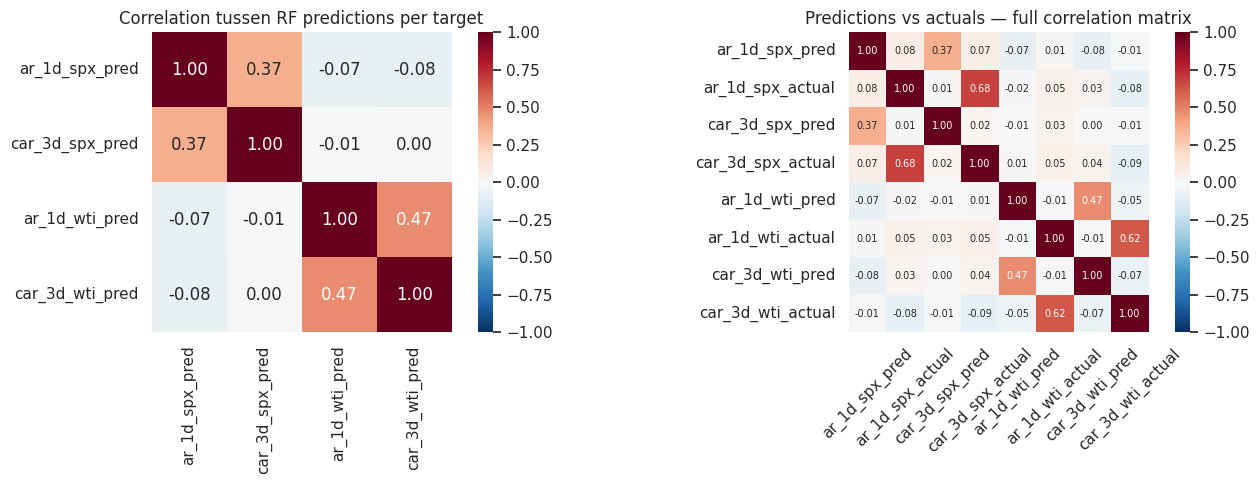

In [ ]:
# Verzamel test-predictions per target voor RF regressor
preds_per_target = {}
for col in TARGET_COLS:
    rf = reg_results[col]["rf"]["model"]
    X_te = reg_results[col]["rf"]["X_test"]
    y_te = reg_results[col]["rf"]["y_test"]
    pred = rf.predict(X_te)
    preds_per_target[f"{col}_pred"] = pd.Series(pred, name=f"{col}_pred")
    preds_per_target[f"{col}_actual"] = pd.Series(y_te, name=f"{col}_actual")

# Predictie-correlatie tussen targets
pred_df = pd.DataFrame({k: v.reset_index(drop=True) for k, v in preds_per_target.items() if k.endswith("_pred")})
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.heatmap(pred_df.corr().round(3), annot=True, fmt=".2f", cmap="RdBu_r",
            center=0, vmin=-1, vmax=1, ax=axes[0], square=True)
axes[0].set_title("Correlation tussen RF predictions per target")

# Predictie ↔ actual correlatie matrix
both = pd.DataFrame({k: v.reset_index(drop=True) for k, v in preds_per_target.items()})
sns.heatmap(both.corr().round(3), annot=True, fmt=".2f", cmap="RdBu_r",
            center=0, vmin=-1, vmax=1, ax=axes[1], square=True,
            annot_kws={"size": 7})
axes[1].set_title("Predictions vs actuals — full correlation matrix")
axes[1].tick_params(axis="x", rotation=45)

fig.tight_layout()
plt.show()

## 7. Save trained models

Eén `.joblib` per (target, model_type, task) zodat notebook 06 ze direct kan
laden voor SHAP/permutation analyse.


In [ ]:
models_dir = Path("../models")
models_dir.mkdir(exist_ok=True)

for col in TARGET_COLS:
    for task, results in [("cls", cls_results[col]), ("reg", reg_results[col])]:
        for name, bundle in results.items():
            if name == "dummy":
                continue
            fname = models_dir / f"{name}_{task}_{col}.joblib"
            joblib.dump(bundle["model"], fname)

# Save metric summary tables
joblib.dump({
    "classification": cls_results,
    "regression": reg_results,
}, models_dir / "all_results.joblib")

# Plain CSV for de scriptie
cls_table.to_csv(models_dir / "metrics_classification.csv")
reg_table.to_csv(models_dir / "metrics_regression.csv")

print(f"Saved to {models_dir.resolve()}:")
for p in sorted(models_dir.iterdir()):
    print(f"  {p.name:40s}  {p.stat().st_size:>10,} bytes")

Saved to /sessions/confident-blissful-clarke/mnt/outputs/truthsocial-marketimpact/models:
  all_results.joblib                        13,767,381 bytes
  logistic_l1_cls_ar_1d_spx.joblib              10,179 bytes
  logistic_l1_cls_ar_1d_wti.joblib              10,179 bytes
  logistic_l1_cls_car_3d_spx.joblib             10,179 bytes
  logistic_l1_cls_car_3d_wti.joblib             10,179 bytes
  metrics_classification.csv                       427 bytes
  metrics_regression.csv                           591 bytes
  rf_cls_ar_1d_spx.joblib                    1,353,649 bytes
  rf_cls_ar_1d_wti.joblib                    1,792,945 bytes
  rf_cls_car_3d_spx.joblib                   1,752,817 bytes
  rf_cls_car_3d_wti.joblib                   1,863,697 bytes
  rf_reg_ar_1d_spx.joblib                    1,127,505 bytes
  rf_reg_ar_1d_wti.joblib                    1,024,257 bytes
  rf_reg_car_3d_spx.joblib                   1,159,185 bytes
  rf_reg_car_3d_wti.joblib                   1,308,657 b

## 8. Bevindingen & next steps

**Wat we nu hebben (synthetic data):**
- 4 RF classifiers + 4 RF regressors getraind, opgeslagen.
- Confusion matrices, pred-vs-actual scatters, residuals — allemaal geëxporteerd.
- Vergelijking RF vs. baselines (Dummy, Logistic-L1, Ridge).

**Wat de cijfers (waarschijnlijk) tonen op synthetic data:**
- RF accuracy ≈ Dummy accuracy. Dat is verwacht: **er is geen signaal** in synth posts.
- Regressie R² is dichtbij 0 of zelfs licht negatief — geen voorspellende kracht.
- Directional accuracy ≈ 0.5 (= random).

Wanneer je dit lokaal runt met **echte** data, verwacht je:
- RF should beat Dummy met enkele percent op accuracy/F1.
- L1-Logistic is een sterke baseline en kan RF heel close benaderen op tekstdata.
- Als RF L1-Logistic niet verslaat, is dat een legitieme bevinding voor je scriptie.

**Volgende stap (notebook 06):**
- Permutation importance op de RF-modellen.
- SHAP values voor top-N posts.
- Top-30 woorden per asset → de hoofdtafel voor je scriptie.

**Open vragen voor begeleider:**
- Hyperparameter tuning met Optuna (TimeSeriesSplit) als robustness check?
- Walk-forward validation toevoegen i.p.v. enkele chronologische split?
- Class imbalance handling: SMOTE, class weights, of dead-zone aanpassen?
